## This file aims to check the accuracy of our factor replication with the research 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
factors = pd.read_csv('../data-replication/factors_copy.csv', index_col=[0], header=[0])
replicated_factors = pd.read_csv('../out_factors/wrds_factors.csv', index_col=[0], header=[0])
idx = factors.index
replicated_factors.index = pd.to_datetime(replicated_factors.index).strftime('%Y%m%d').astype(int)
replicated_factors = replicated_factors.loc[idx, :]

replicated_factors.columns

Index(['IPO', 'acc', 'cashdebt', 'convind', 'currat', 'depr', 'divi', 'divo',
       'HML', 'lev', 'mom36m', 'mom6m', 'pchcurrat', 'pchdepr',
       'pchgm_pchsale', 'pchquick', 'pchsaleinv', 'pps', 'quick', 'salecash',
       'saleinv', 'salerec', 'sgr', 'SMB', 'turn'],
      dtype='object')

In [3]:
factors = factors[sorted(factors.columns)]

factors = factors[replicated_factors.columns]
factors

,IPO,acc,cashdebt,convind,currat,depr,divi,divo,HML,lev,...,pchquick,pchsaleinv,pps,quick,salecash,saleinv,salerec,sgr,SMB,turn
Date,,,,,,,,,,,,,,,,,,,,,
19760730,-0.009577,0.009829,0.008416,0.006419,0.012896,-0.010338,0.000459,0.003217,0.0174,0.014287,...,-0.001588,0.009088,0.022795,-0.013352,-0.002343,0.006370,0.017471,-0.010434,0.0030,-0.027540
19760831,-0.009147,-0.008397,0.014410,0.011942,0.019217,-0.020992,-0.009732,-0.031130,0.0079,0.012798,...,-0.002034,-0.004693,-0.012378,-0.017689,-0.012452,0.005035,0.007916,-0.018296,-0.0201,-0.033931
19760930,-0.015013,-0.009093,-0.016048,0.004950,0.005109,0.004286,0.003439,-0.015354,-0.0029,-0.005758,...,-0.003710,0.001697,-0.013977,-0.000494,0.013296,0.011307,0.002462,-0.014130,0.0000,0.006262
19761029,-0.005945,-0.007480,0.005865,0.008094,0.012861,-0.013067,-0.003264,-0.022888,-0.0013,0.005461,...,0.000531,-0.009903,-0.005516,-0.016451,-0.011213,0.016077,0.020488,-0.002209,0.0025,-0.027097
19761130,-0.018339,0.008946,0.026686,0.002652,0.010043,0.002220,0.038232,-0.013680,0.0151,0.025121,...,-0.000482,-0.003363,0.012752,-0.015365,-0.016895,0.017597,0.017777,-0.001430,0.0232,0.021370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20170831,0.027037,0.000950,-0.012258,0.016428,-0.003199,0.022568,0.006214,0.027174,-0.0226,-0.013204,...,-0.011904,0.004415,-0.012115,0.015502,0.019437,0.024367,-0.006904,0.000122,-0.0171,-0.015106
20170929,0.001469,0.002445,0.006344,0.011053,-0.013092,-0.018141,0.020617,0.006492,0.0302,0.002569,...,0.009469,-0.015789,0.014507,-0.000921,-0.016446,-0.025262,-0.011173,0.018952,0.0453,0.013113
20171031,0.023853,0.017047,-0.026886,-0.021940,-0.009801,0.008626,0.026931,0.004185,-0.0008,-0.031495,...,-0.018733,0.010414,-0.042406,0.018460,0.020084,0.001520,-0.002116,-0.003472,-0.0195,-0.010159


In [4]:
def _align_frames(A: pd.DataFrame, B: pd.DataFrame, cols=None):
    common_idx = A.index.intersection(B.index)
    common_cols = A.columns.intersection(B.columns) if cols is None else pd.Index(cols).intersection(A.columns).intersection(B.columns)
    A1 = A.loc[common_idx, common_cols].sort_index()
    B1 = B.loc[common_idx, common_cols].sort_index()
    return A1, B1, list(common_cols)

def lin_ccc(x: pd.Series, y: pd.Series):
    df = pd.concat([x, y], axis=1).dropna()
    if df.shape[0] < 2:
        return np.nan
    x = df.iloc[:,0].values
    y = df.iloc[:,1].values
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sdx, sdy = np.sqrt(vx), np.sqrt(vy)
    r = np.corrcoef(x, y)[0,1] if sdx > 0 and sdy > 0 else np.nan
    denom = vx + vy + (mx - my)**2
    if denom == 0:
        return np.nan
    return 2 * r * sdx * sdy / denom

In [5]:
def compute_column_metrics(factors: pd.DataFrame,
                           df_mapped_ci: pd.DataFrame,
                           cols=None,
                           standardize=False,
                           eps=1e-12):
    A, B, used_cols = _align_frames(factors, df_mapped_ci, cols)
    rows = []
    for c in used_cols:
        pair = pd.concat([A[c], B[c]], axis=1, keys=['A','B']).dropna()
        n = len(pair)
        if n == 0:
            rows.append({
                'col': c, 'n': 0, 'pearson': np.nan, 'spearman': np.nan, 'r2': np.nan,
                'rmse': np.nan, 'mae': np.nan, 'mape': np.nan, 'bias_mean(A-B)': np.nan,
                'std_diff': np.nan, 'ccc': np.nan
            })
            continue

        x = pair['A'].to_numpy(dtype=float)
        y = pair['B'].to_numpy(dtype=float)

        if standardize:
            def zscore(v):
                v = v.copy()
                m, s = np.nanmean(v), np.nanstd(v, ddof=1)
                return (v - m) / (s if s > 0 else 1.0)
            x = zscore(x)
            y = zscore(y)

        err = x - y
        rmse = float(np.sqrt(np.mean(err**2)))
        mae  = float(np.mean(np.abs(err)))
        mape = float(np.mean(np.abs(err) / np.maximum(np.abs(y), eps)))

        if np.std(x, ddof=1) > 0 and np.std(y, ddof=1) > 0:
            pearson = float(np.corrcoef(x, y)[0,1])
            spearman = float(pd.Series(x).corr(pd.Series(y), method='spearman'))
            r2 = float(pearson**2)
        else:
            pearson = spearman = r2 = np.nan

        ccc = float(lin_ccc(pd.Series(x), pd.Series(y)))

        rows.append({
            'col': c,
            'n': n,
            'pearson': pearson,
            'spearman': spearman,
            'r2': r2,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'bias_mean(A-B)': float(np.mean(err)),
            'std_diff': float(np.std(err, ddof=1)) if n > 1 else 0.0,
            'ccc': ccc,
        })
    out = pd.DataFrame(rows).set_index('col')
    return out.sort_values('rmse', na_position='last')

In [6]:
def plot_compare(factors: pd.DataFrame,
                 df_mapped_ci: pd.DataFrame,
                 col: str,
                 kind='timeseries',
                 standardize=False):
    """
    kind ∈ {'timeseries', 'scatter', 'diff'}
    """
    A, B, _ = _align_frames(factors, df_mapped_ci, cols=[col])
    pair = pd.concat([A[col], B[col]], axis=1, keys=['A','B']).dropna()
    if pair.empty:
        raise ValueError(f'No overlapping non-NaN data for column: {col}')

    x = pair['A'].copy()
    y = pair['B'].copy()

    if standardize:
        def zscore(s):
            m, sd = s.mean(), s.std(ddof=1)
            return (s - m) / (sd if sd > 0 else 1.0)
        x = zscore(x)
        y = zscore(y)

    if kind == 'timeseries':
        plt.figure()
        x.plot()
        y.plot()
        plt.title(f'{col} (A=factors, B=df_mapped_ci)')
        plt.legend(['A', 'B'])
        plt.xlabel('index')
        plt.ylabel(col)
        plt.show()

    elif kind == 'scatter':
        plt.figure()
        plt.scatter(x, y, s=10)
        lo = np.nanmin([x.min(), y.min()])
        hi = np.nanmax([x.max(), y.max()])
        plt.plot([lo, hi], [lo, hi])
        plt.title(f'{col}: A vs B (y=x line)')
        plt.xlabel('A (factors)')
        plt.ylabel('B (df_mapped_ci)')
        plt.show()

    elif kind == 'diff':
        plt.figure()
        (x - y).plot()
        plt.title(f'{col}: (A - B)')
        plt.xlabel('index')
        plt.ylabel('A - B')
        plt.show()

    else:
        raise ValueError("kind must be one of {'timeseries','scatter','diff'}")

In [7]:
def rank_columns(factors, df_mapped_ci, by='rmse', ascending=True, top=20, **kwargs):
    met = compute_column_metrics(factors, df_mapped_ci, **kwargs)
    return met.sort_values(by, ascending=ascending).head(top)

In [8]:
metrics = compute_column_metrics(factors, replicated_factors, standardize=False)
print(f"Number of factors compared: {metrics.shape[0]}")
display(metrics)

Number of factors compared: 25


,n,pearson,spearman,r2,rmse,mae,mape,bias_mean(A-B),std_diff,ccc
col,,,,,,,,,,
salecash,498,0.994837,0.989810,0.989700,0.002940,0.002329,0.929339,0.000428,0.002912,0.994636
pchdepr,498,0.967082,0.938163,0.935248,0.003232,0.002471,1.843229,-0.000154,0.003231,0.965929
convind,498,0.975248,0.971049,0.951108,0.003251,0.002384,1.391748,-0.000339,0.003237,0.973867
salerec,498,0.987661,0.984999,0.975475,0.003355,0.002496,1.118863,-0.000254,0.003349,0.987586
pchsaleinv,498,0.958457,0.934467,0.918639,0.003644,0.002687,1.593737,-0.000088,0.003647,0.958377
saleinv,498,0.979802,0.977411,0.960012,0.003663,0.002660,1.093320,-0.000230,0.003660,0.979641
pchgm_pchsale,498,0.956082,0.948628,0.914093,0.003911,0.002918,1.612698,-0.000091,0.003914,0.956003
acc,354,0.967503,0.952582,0.936062,0.004301,0.002851,3.965174,0.000267,0.004299,0.967311
pchquick,498,0.909818,0.879431,0.827770,0.004627,0.003412,1.355101,-0.000331,0.004620,0.908231


In [9]:
worst = rank_columns(factors, replicated_factors, by='pearson', ascending=False)
print(worst)

                 n   pearson  spearman        r2      rmse       mae  \
col                                                                    
salecash       498  0.994837  0.989810  0.989700  0.002940  0.002329   
quick          498  0.988043  0.977728  0.976230  0.005071  0.003601   
salerec        498  0.987661  0.984999  0.975475  0.003355  0.002496   
currat         498  0.983653  0.977166  0.967573  0.005998  0.004224   
saleinv        498  0.979802  0.977411  0.960012  0.003663  0.002660   
convind        498  0.975248  0.971049  0.951108  0.003251  0.002384   
depr           498  0.969923  0.958971  0.940751  0.007880  0.005830   
acc            354  0.967503  0.952582  0.936062  0.004301  0.002851   
SMB            498  0.967240  0.962040  0.935553  0.008645  0.006079   
pchdepr        498  0.967082  0.938163  0.935248  0.003232  0.002471   
lev            498  0.963027  0.946066  0.927422  0.008676  0.006246   
pchsaleinv     498  0.958457  0.934467  0.918639  0.003644  0.00

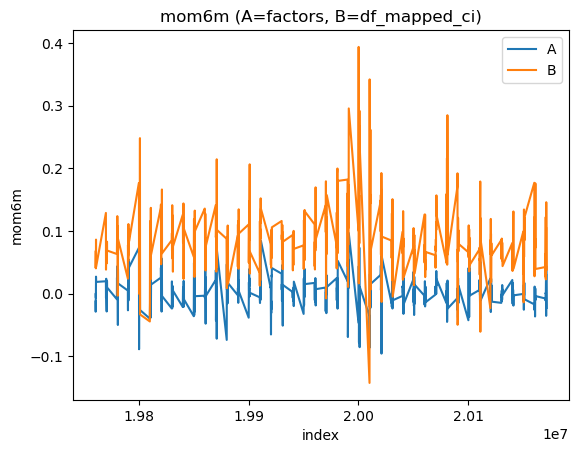

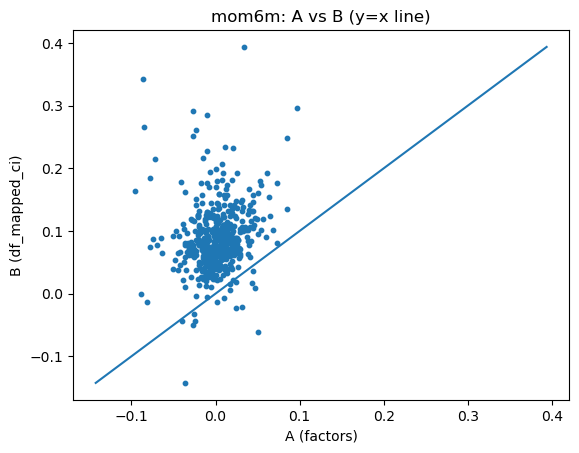

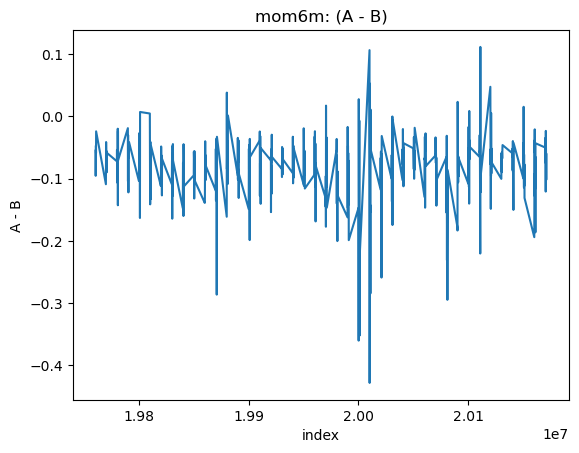

In [ ]:
plot_compare(factors, replicated_factors, col='mom6m', kind='timeseries')
plot_compare(factors, replicated_factors, col='mom6m', kind='scatter')
plot_compare(factors, replicated_factors, col='mom6m', kind='diff')